# Choosing the best optimizer for you 
In this how-to, we will show you how to use `dygdug` with `prysm.x.optym`'s optimizers to search for the best optimizer for your problem. This tutorial picks up where we left off in the Optimizing Coronagraphs how-to, so we will start by setting up the problem as we did before, first with the `Coronagraph` object 

In [1]:
import matplotlib.pyplot as plt
from prysm.propagation import prepare_executor 
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np
from tqdm import tqdm

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph


# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 512
Nfoc = 128
wvl = 1 
fno = 13.66
efl = fno * circumscribed_diameter 
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4 # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800

# Define VARIABLE entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter, 
    Npup=Npup,
    rings=3,                 
    segment_diameter=seg_diam, 
    segment_separation=5, 
    # exclude=(0,),
    mode="phase" # special argument for VariablePupil
)

# ensure we are using the GPU backend
set_backend_to_cupy()

# update the VariablePupil data to be a cupy array
pupil.data = np.asarray(pupil.data)

# Define a prysm executor the controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Next we set up the optimization problem

In [2]:
from dygdug.coropt import CoronagraphOptimizer
from dygdug.cost_functions import FieldMeanSquaredError
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Define Image Plane Sampling Specification and Dark Hole
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

# Define cost function
target_contrast = 1e-10
target_field = np.sqrt(target_contrast)
cost_function = FieldMeanSquaredError(target=target_field)

# Define the starting parameter vector
x0 = np.zeros_like(pupil.data[pupil.mask], dtype="float64")

# Define the CoronagraphOptimizer
coroopt = CoronagraphOptimizer(
    dark_hole=dark_hole,
    coro=coro,
    wvl=[wvl], # just perform monochromatic for now
    cost=cost_function
)


Next, we import the `optym` optimizers. This how-to will be organized by each optimizer currently available in `prysm`. 

# Gradient Descent

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:02<00:00, 356.44it/s]


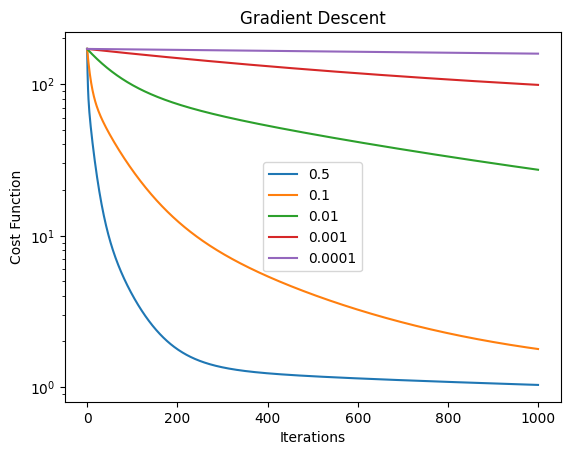

In [3]:
from prysm.x.optym import GradientDescent
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = GradientDescent(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("Gradient Descent")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# AdaGrad

100%|██████████| 1000/1000 [00:02<00:00, 352.31it/s]


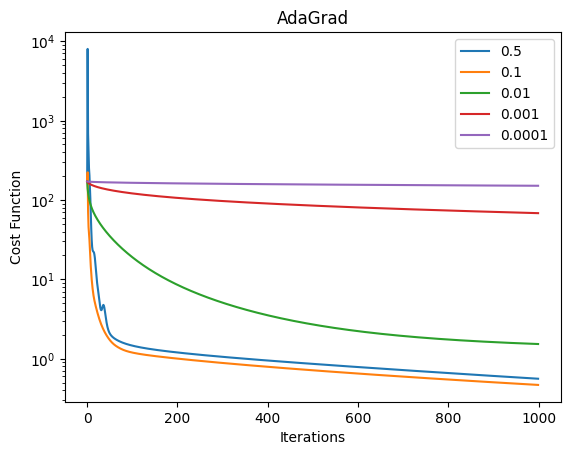

In [4]:
from prysm.x.optym import AdaGrad
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = AdaGrad(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("AdaGrad")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# RMSProp

100%|██████████| 1000/1000 [00:02<00:00, 350.79it/s]


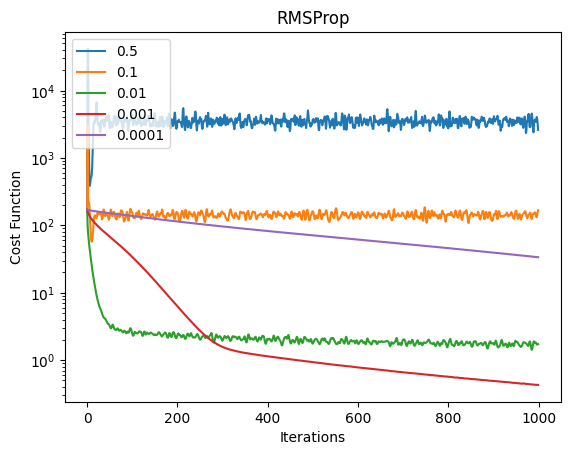

In [5]:
from prysm.x.optym import RMSProp
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = RMSProp(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("RMSProp")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# Adam

100%|██████████| 1000/1000 [00:02<00:00, 347.89it/s]


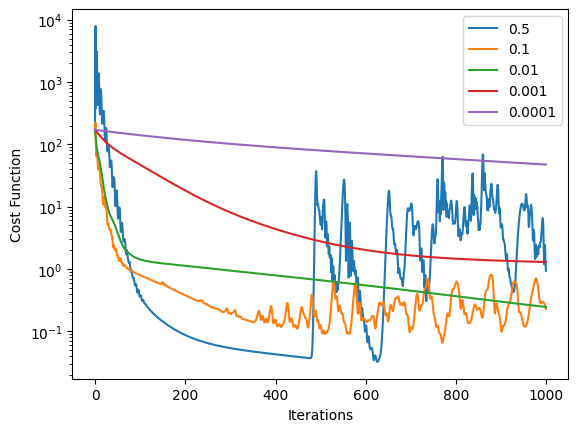

In [6]:
from prysm.x.optym import Adam 
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = Adam(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# RAdam

100%|██████████| 1000/1000 [00:02<00:00, 346.02it/s]


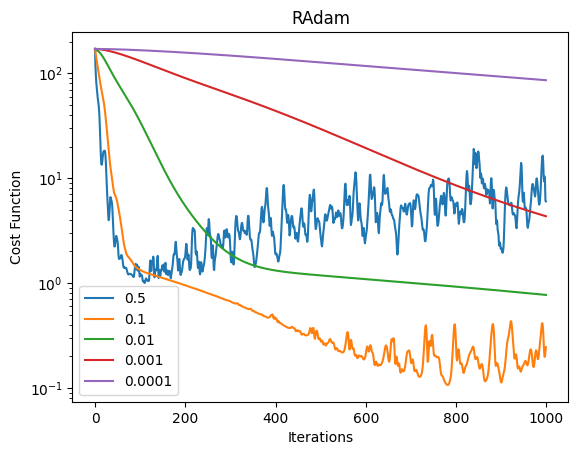

In [7]:
from prysm.x.optym import RAdam
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = RAdam(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("RAdam")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# AdaMomentum

100%|██████████| 1000/1000 [00:02<00:00, 346.99it/s]


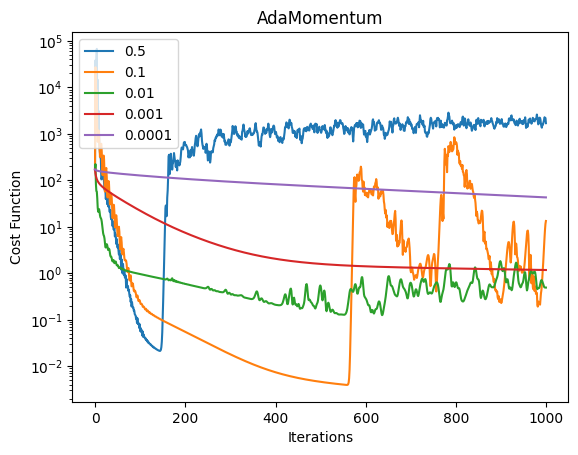

In [8]:
from prysm.x.optym import AdaMomentum
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = AdaMomentum(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("AdaMomentum")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# Yogi

100%|██████████| 1000/1000 [00:02<00:00, 346.01it/s]


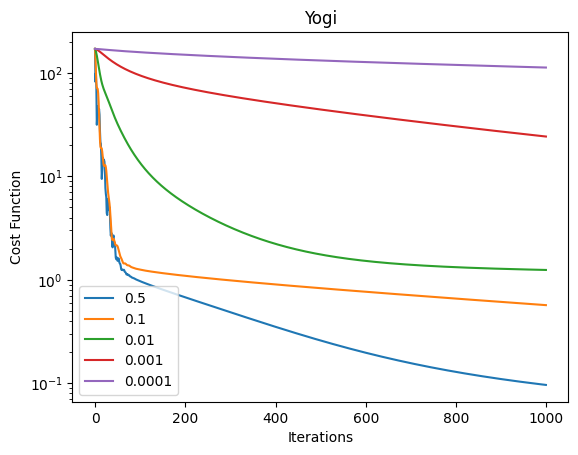

In [9]:
from prysm.x.optym import Yogi
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = Yogi(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("Yogi")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

# L-BFGS
Unbounded L-BFGS is quite nice because it's faster, and finds good solutions. Let's try add progressive refinement to solve for a "best" PAPLC

100%|██████████| 2000/2000 [00:13<00:00, 147.21it/s]


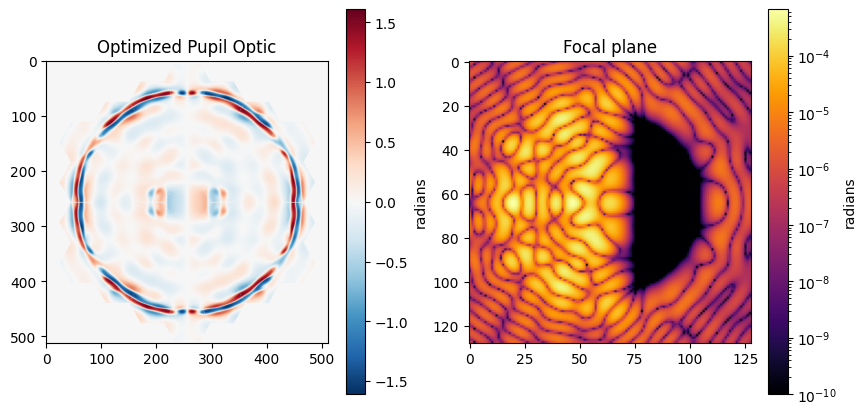

In [11]:
from prysm.x.optym import PrysmLBFGSB
from matplotlib.colors import LogNorm

N_OUTER = 10
N_INNER = 2000

# Re-set the solution
coro.pupil.update(x0)

opt = PrysmLBFGSB(fg=coroopt.fg, x0=x0, memory=10)
cost = []

for i in range(N_OUTER):

    # Perform inner solution finding
    for j in tqdm(range(N_INNER)):
        opt.step()
        cost.append(coroopt.J)

    # provide a "kick" to the solution
    if i < (N_OUTER - 1):
        opt.x *= 0.7

xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

In [12]:
np.max(np.abs(np.angle(pupil.data))) / np.pi

array(0.51258347)

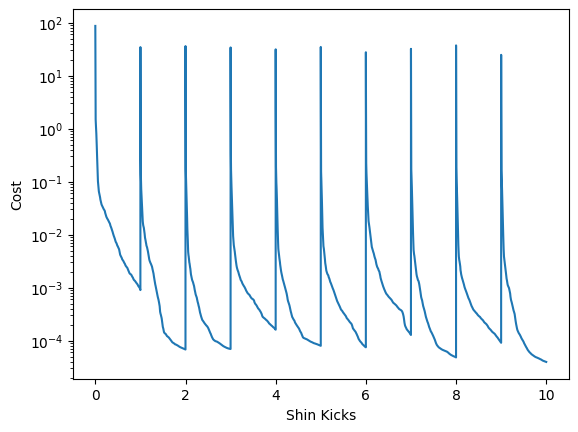

In [20]:
kicks = np.arange(N_INNER * N_OUTER).astype(np.float64)
kicks /= np.float64(N_INNER)

plt.figure()
plt.plot(kicks.get(), cost)
plt.yscale("log")
plt.ylabel("Cost")
plt.xlabel("Shin Kicks")
plt.show()